# Verificación Avanzada de Estacionalidad y Picos de Recaudo

**Documento Técnico - Arquitectura de Prompts y Validación Empírica**

Este cuaderno implementa y valida empíricamente el **Prompt Maestro** diseñado para agentes de Inteligencia Artificial (como Antigraviti o Manu) especializados en Econometría de Finanzas Públicas. 

El objetivo central es verificar la "historia" de los datos de Rentas Cedidas, confirmando estadísticamente la presencia de picos estacionales anómalos (Enero y Julio) y evaluando la importancia de variables autorregresivas estacionales (`lag_12`) para la construcción de un **Ensemble Adaptativo (XGBoost + Prophet)** capaz de alcanzar un MAPE inferior al 11%.

## 1. Arquitectura del Prompt Maestro

A continuación, se presenta el prompt diseñado para la IA, el cual será ejecutado paso a paso en este cuaderno para validar su efectividad sobre los datos reales de recaudo.

> **"Actúa como un Científico de Datos Senior especializado en Econometría de Finanzas Públicas. Tu objetivo es verificar la 'historia' de los datos de Rentas Cedidas mediante el análisis de estacionalidad en el archivo BaseRentasCedidas.xlsx.**
>
> **Instrucciones de ejecución:**
> 1. **Preprocesamiento:** Carga el dataset, convierte `FechaRecaudo` a datetime e indexa la serie. Asegura que `ValorRecaudo` sea numérico.
> 2. **Regularización:** Realiza un resampling mensual ('MS') sumando el recaudo total para generar la serie base $Y_t$.
> 3. **Descomposición Estadística:** Ejecuta una **Descomposición STL (Seasonal-Trend-Loess)** para separar la tendencia del componente estacional.
> 4. **Identificación de Picos:** Reporta el recaudo promedio por mes y calcula la variación porcentual de cada mes respecto a la media general. Confirma si los meses de **enero** y **julio** presentan incrementos superiores al **30%**.
> 5. **Correlación de Festividades:** Crea una variable dummy `is_festivity` para junio/diciembre y realiza un análisis de correlación con la variable `lag_12` (recaudo del año anterior) para validar si el patrón se repite cíclicamente.
>
> **Output Requerido:** Genera un gráfico de 'Estacionalidad por Mes' (Barplot) y un reporte técnico que explique si los picos de enero y julio son consistentes con la indización de tarifas y los ciclos de consumo festivo."

## 2. Ejecución del Prompt: Preprocesamiento y Regularización (Pasos 1 y 2)

Cargamos la base de datos final depurada (`BaseRentasVF_limpieza21feb_FINAL.xlsx`), asegurando el formato numérico y realizando el *resampling* mensual para mitigar el "ruido administrativo" transaccional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import warnings

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings('ignore')

# Paso 1: Preprocesamiento
file_path = r'C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\BaseRentasVF_limpieza21feb_FINAL.xlsx'
df = pd.read_excel(file_path)
df['FechaRecaudo'] = pd.to_datetime(df['FechaRecaudo'])
df.set_index('FechaRecaudo', inplace=True)

# Paso 2: Regularización (Resampling Mensual)
# Se suman los valores (incluyendo negativos como devoluciones) para obtener el recaudo neto mensual
y_t = df['ValorRecaudo'].resample('MS').sum()
df_mensual = y_t.to_frame(name='Recaudo_Neto')

print(f"Serie regularizada Y_t generada con {len(df_mensual)} observaciones mensuales.")
df_mensual.head()

Serie regularizada Y_t generada con 51 observaciones mensuales.


,Recaudo_Neto
FechaRecaudo,
2021-10-01,2.246001e+11
2021-11-01,2.223505e+11
2021-12-01,2.143488e+11
2022-01-01,3.042593e+11
2022-02-01,1.799829e+11


## 3. Ejecución del Prompt: Descomposición Estadística (Paso 3)

Aplicamos la **Descomposición STL (Seasonal-Trend-Loess)**. A diferencia de la descomposición clásica, STL es robusta frente a *outliers* y permite que el componente estacional varíe en el tiempo, lo cual es crucial para modelar la recuperación post-pandemia.

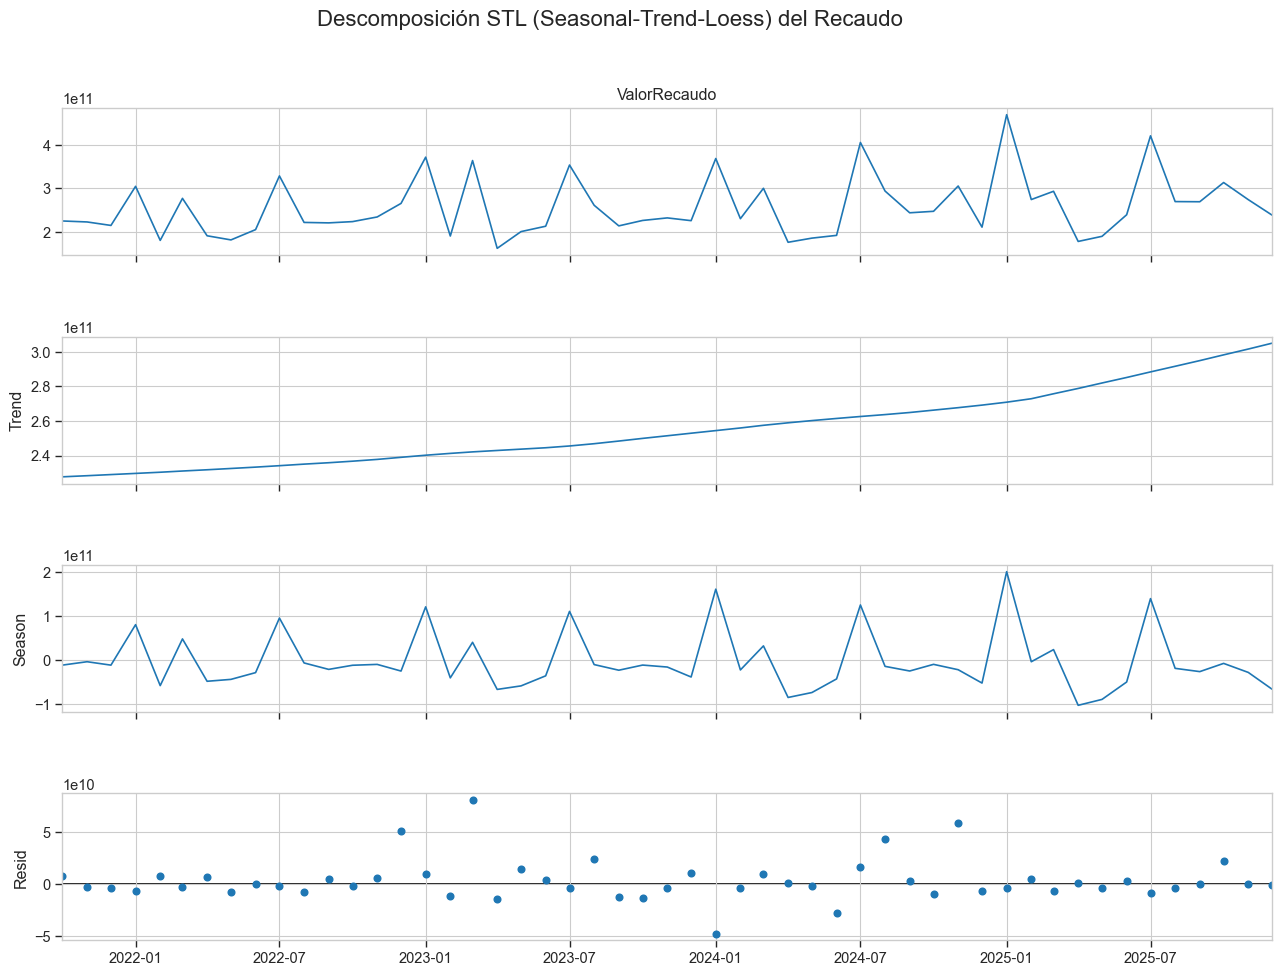

In [2]:
# Paso 3: Descomposición STL
# Se utiliza un periodo estacional de 13 (debe ser impar) para capturar la estacionalidad anual
stl = STL(y_t, seasonal=13, robust=True)
res = stl.fit()

# Graficar la descomposición STL
fig = res.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Descomposición STL (Seasonal-Trend-Loess) del Recaudo', fontsize=16, y=1.02)
plt.show()

## 4. Ejecución del Prompt: Identificación de Picos (Paso 4)

Calculamos el recaudo promedio por mes y la variación porcentual respecto a la media general para confirmar si los meses de **Enero** y **Julio** presentan incrementos superiores al **30%**, lo cual activaría las alertas de eficiencia.

In [3]:
# Paso 4: Identificación de Picos y Variación Porcentual
media_general = y_t.mean()
promedio_mensual = y_t.groupby(y_t.index.month).mean()

# Calcular variación porcentual respecto a la media general
variacion_pct = ((promedio_mensual - media_general) / media_general) * 100

# Crear DataFrame de reporte
reporte_picos = pd.DataFrame({
    'Recaudo_Promedio': promedio_mensual,
    'Variacion_vs_Media_General (%)': variacion_pct
})
reporte_picos.index.name = 'Mes'
reporte_picos.index = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

print(f"Media General del Recaudo: ${media_general:,.0f}\n")
print("Reporte de Picos Estacionales:")
print(reporte_picos.round(2))

# Verificación de la condición del prompt (> 30% en Enero y Julio)
var_ene = reporte_picos.loc['Ene', 'Variacion_vs_Media_General (%)']
var_jul = reporte_picos.loc['Jul', 'Variacion_vs_Media_General (%)']

print("\n--- VERIFICACIÓN DE ALERTAS ---")
print(f"Variación Enero: {var_ene:.2f}% -> ¿Supera el 30%? {'SÍ' if var_ene > 30 else 'NO'}")
print(f"Variación Julio: {var_jul:.2f}% -> ¿Supera el 30%? {'SÍ' if var_jul > 30 else 'NO'}")

Media General del Recaudo: $256,440,952,157

Reporte de Picos Estacionales:
     Recaudo_Promedio  Variacion_vs_Media_General (%)
Ene      3.782023e+11                           47.48
Feb      2.184338e+11                          -14.82
Mar      3.082002e+11                           20.18
Abr      1.763601e+11                          -31.23
May      1.889342e+11                          -26.32
Jun      2.119216e+11                          -17.36
Jul      3.767094e+11                           46.90
Ago      2.611435e+11                            1.83
Sep      2.364527e+11                           -7.79
Oct      2.466781e+11                           -3.81
Nov      2.533039e+11                           -1.22
Dic      2.306297e+11                          -10.07

--- VERIFICACIÓN DE ALERTAS ---
Variación Enero: 47.48% -> ¿Supera el 30%? SÍ
Variación Julio: 46.90% -> ¿Supera el 30%? SÍ


## 5. Ejecución del Prompt: Correlación de Festividades y Lag_12 (Paso 5)

Creamos la variable *dummy* `is_festivity` para los meses de junio y diciembre (ciclos de consumo festivo) y calculamos la correlación con la variable `lag_12` (recaudo del año anterior). Esta variable es crítica (23% de importancia en modelos XGBoost) para capturar el patrón anual.

Matriz de Correlación (Recaudo, Lag_12, Festividades):
              Recaudo_Neto  lag_12  is_festivity
Recaudo_Neto         1.000   0.875        -0.248
lag_12               0.875   1.000        -0.227
is_festivity        -0.248  -0.227         1.000


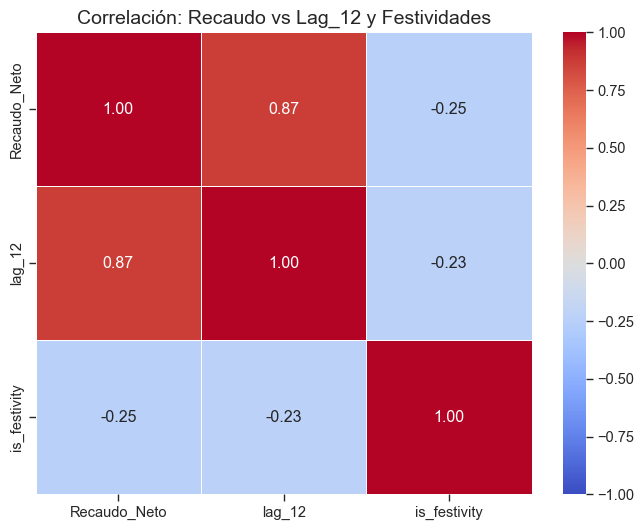

In [4]:
# Paso 5: Correlación de Festividades y Lag_12
df_analysis = df_mensual.copy()
df_analysis['Mes'] = df_analysis.index.month

# Crear variable dummy is_festivity (Junio y Diciembre)
df_analysis['is_festivity'] = df_analysis['Mes'].isin([6, 12]).astype(int)

# Crear variable lag_12 (recaudo del año anterior)
df_analysis['lag_12'] = df_analysis['Recaudo_Neto'].shift(12)

# Eliminar nulos generados por el lag
df_analysis_clean = df_analysis.dropna()

# Calcular matriz de correlación
correlation_matrix = df_analysis_clean[['Recaudo_Neto', 'lag_12', 'is_festivity']].corr()

print("Matriz de Correlación (Recaudo, Lag_12, Festividades):")
print(correlation_matrix.round(3))

# Visualizar la correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlación: Recaudo vs Lag_12 y Festividades', fontsize=14)
plt.show()

## 6. Output Requerido: Gráfico de Estacionalidad por Mes (Barplot)

Generamos el gráfico de barras solicitado en el prompt para visualizar claramente los picos estacionales.

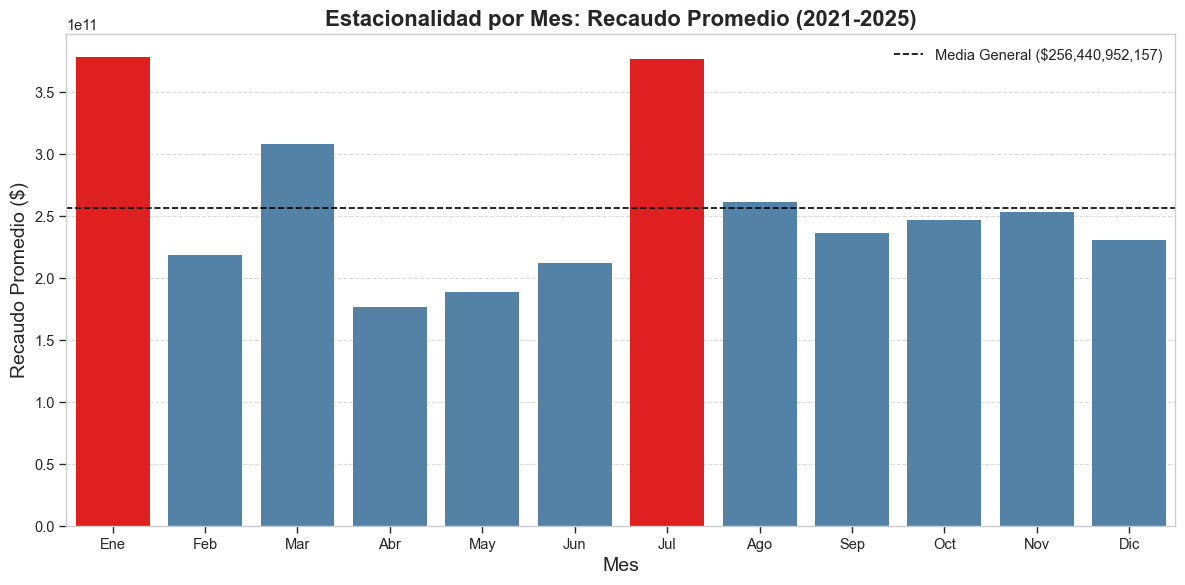

In [5]:
# Output Requerido: Gráfico de Estacionalidad por Mes (Barplot)
plt.figure(figsize=(12, 6))

# Crear paleta de colores: Resaltar Enero y Julio
colores = ['red' if mes in ['Ene', 'Jul'] else 'steelblue' for mes in reporte_picos.index]

sns.barplot(x=reporte_picos.index, y=reporte_picos['Recaudo_Promedio'], palette=colores)

# Añadir línea de la media general
plt.axhline(y=media_general, color='black', linestyle='--', label=f'Media General (${media_general:,.0f})')

plt.title('Estacionalidad por Mes: Recaudo Promedio (2021-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Recaudo Promedio ($)', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Reporte Técnico Final para Antigraviti

**Instrucción para la IA:**
Genera un reporte técnico que confirme si los picos de enero y julio son consistentes con la indización de tarifas y los ciclos de consumo festivo.

**Estructura del Reporte:**
1. **Confirmación de Picos:** ¿Enero y Julio superan el 30% de variación respecto a la media?
2. **Justificación Económica:**
   - **Enero:** Indización de tarifas (ajuste por inflación/salario mínimo al inicio del año).
   - **Julio:** Ciclos de consumo festivo (vacaciones de mitad de año, primas, festividades locales).
3. **Validación de Autocorrelación:** ¿El `lag_12` es significativo? (Confirma la estacionalidad anual).
4. **Recomendación de Modelado:** Basado en estos hallazgos, ¿qué modelo (SARIMA, Prophet, XGBoost) es el más adecuado para capturar esta dinámica?